In [78]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
import torch.optim as optim
import matplotlib.pyplot as plt

from einops import rearrange
from einops.layers.torch import Rearrange

In [ ]:
transform = transforms.Compose([
    # transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), 
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

In [80]:
train_dataset = CIFAR10(root=".", train=True, transform=train_transform, download=True)
test_dataset = CIFAR10(root=".", train=False, transform=transform, download=True)

In [81]:
num_workers = 2
batch = 512

train_loader = DataLoader(dataset=train_dataset, batch_size=batch, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch, shuffle=True, num_workers=num_workers)

In [82]:
import torch.nn as nn
import torch.nn.functional as F

In [83]:
class FeedForward(nn.Module):
  def __init__(self, dim, dim_mlp):
    super().__init__()

    self.ffn = nn.Sequential(
        nn.LayerNorm(dim),
        nn.Linear(dim, dim_mlp),
        nn.GELU(),
        nn.Linear(dim_mlp, dim)
    )

  def forward(self, x):
    return self.ffn(x)

In [84]:
class Attention(nn.Module):
  def __init__(self, dim, heads=8, dim_head=64):
    super().__init__()

    self.heads = heads
    inner_dim = heads * dim_head
    self.scale = dim_head ** -0.5 # FIX :>>>
    self.norm = nn.LayerNorm(dim)

    self.attend = nn.Softmax(dim = -1)

    self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)
    self.to_out = nn.Linear(inner_dim, dim, bias=False)

  def forward(self, x):
    x = self.norm(x)

    qkv = self.to_qkv(x) # shape [b, n, inner_dim * 3]
    qkv = qkv.chunk(3, dim=-1) # shape 3 tuple -> 3 * [b, n, inner_dim]

    q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv) ## FIX SHAPE

    dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

    out = self.attend(dots)
    out = torch.matmul(out, v)
    out = rearrange(out, 'b h n d -> b n (h d)')
    out = self.to_out(out)
    return out


In [85]:
class Transformer_Encoder(nn.Module):
  def __init__(self, dim, depth, heads, dim_head, dim_mlp):
    super().__init__()

    self.depth = depth
    self.norm = nn.LayerNorm(dim)
    self.layers = nn.ModuleList([])

    for _ in range(depth):
      self.layers.append(nn.ModuleList([
          Attention(dim=dim, heads=heads, dim_head=dim_head),
          FeedForward(dim, dim_mlp),
      ]))

  def forward(self, x):
    for att, ffn in self.layers:
      x = att(x) + x
      x = ffn(x) + x
    x = self.norm(x)
    return x

In [86]:
class ViT(nn.Module):
  def __init__(self, dim, depth, heads, dim_head, dim_mlp, num_classes, patch_size = 8, in_channels = 3):
    super().__init__()

    num_patches = (32 // patch_size) ** 2
    self.in_features = in_channels * patch_size * patch_size
    self.patch_size = patch_size

    self.proj = nn.Linear(self.in_features, dim)

    self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
    self.poisition_encoder = nn.Parameter(torch.randn(1, num_patches+1, dim) * 0.02)

    self.transformer = Transformer_Encoder(dim, depth, heads, dim_head, dim_mlp)

    self.to_latent = nn.Identity()
    self.linear_head = nn.Linear(dim, num_classes)
  def forward(self, x):
    b, c, h, w = x.shape
    x = rearrange(x, 'b c (h p1) (w p2) -> b (h w) (c p1 p2)', p1=self.patch_size, p2=self.patch_size)

    x = self.proj(x)

    cls_tokens = self.cls_token.expand(b, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)

    x = x + self.poisition_encoder
    x = self.transformer(x)

    x = x[:, 0]

    x = self.to_latent(x)
    return self.linear_head(x)

In [87]:
def evaluation(model, critation, test_loader):
  model.eval()
  loss_eval = 0.0

  with torch.no_grad():
    for image, target in test_loader:
      image = image.to(device)
      target = target.to(device)

      pred = model(image)
      loss = critation(pred, target)
      loss_eval += loss.item()

  loss_eval /= len(test_loader)
  return loss_eval

In [88]:
model = ViT(
    dim=512,
    depth=8,
    heads=8,
    dim_head=32,
    dim_mlp=512,
    num_classes=10,
    patch_size=4
)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

critation = nn.CrossEntropyLoss()
lr = 0.0001
epochs = 20
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-2)

In [89]:
from tqdm import tqdm
for epoch in range(epochs):
  loss_train = 0.0
  model.train()
  for image, target in tqdm(train_loader):
    image = image.to(device)
    target = target.to(device)

    optimizer.zero_grad()
    pred = model(image)
    loss = critation(pred, target)
    loss.backward()
    loss_train += loss.item()

    optimizer.step()

  loss_train /= len(train_loader)
  loss_test = evaluation(model, critation, test_loader)

  print(f"Epochs: {epoch}/{epochs}")
  print(f"train loss: {loss_train}")
  print(f"test loss: {loss_test}")

100%|██████████| 98/98 [01:09<00:00,  1.41it/s]


Epochs: 0/20
train loss: 1.8469397814906374
test loss: 1.6885315001010894


100%|██████████| 98/98 [01:05<00:00,  1.50it/s]


Epochs: 1/20
train loss: 1.578066160484236
test loss: 1.5673229455947877


100%|██████████| 98/98 [01:04<00:00,  1.51it/s]


...

Epochs: 17/20
train loss: 0.7151318350616767
test loss: 0.8390670865774155


100%|██████████| 98/98 [01:05<00:00,  1.50it/s]


Epochs: 18/20
train loss: 0.683873966032145
test loss: 0.8277046799659729


100%|██████████| 98/98 [01:05<00:00,  1.50it/s]


Epochs: 19/20
train loss: 0.6662718306998817
test loss: 0.8150774985551834


pred lable: cat
true label: cat


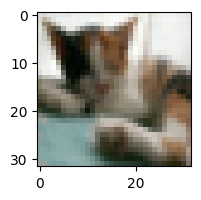

pred lable: bird
true label: bird


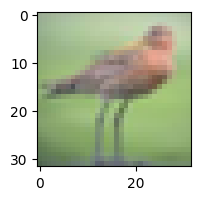

pred lable: frog
true label: frog


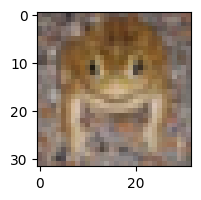

pred lable: frog
true label: frog


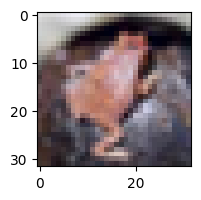

pred lable: automobile
true label: automobile


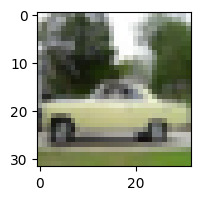

pred lable: frog
true label: frog


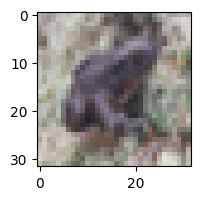

pred lable: automobile
true label: automobile


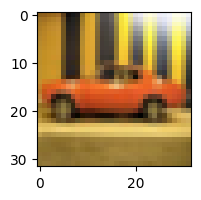

pred lable: frog
true label: deer


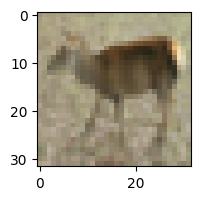

pred lable: truck
true label: cat


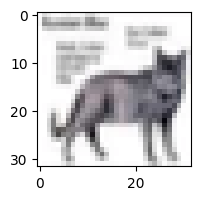

pred lable: cat
true label: cat


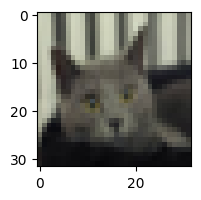

0.8


In [91]:
model.eval()
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

images, labels = next(iter(test_loader))

images = images[:10].to(device)
labels = labels[:10]

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

acc = 0;
for i in range(10):
    true_label = classes[labels[i].item()]
    pred_label = classes[preds[i].item()]
    acc += (true_label == pred_label)

    print(f"pred lable: {pred_label}")
    print(f"true label: {true_label}")

    img = images[i].cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()

    import numpy as np
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.show()
print(f"{acc/10}")